In [7]:
import math as m
import os, sys
import numpy as np
import argparse
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')
import csv

import MDAnalysis as mda
# from MDAnalysis.tests.datafiles import TPR, XTC
from MDAnalysis import transformations
from MDAnalysis.analysis.rdf import InterRDF
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
from MDAnalysis.transformations import wrap, unwrap
import solvation_analysis
from solvation_analysis import Solute
from solvation_analysis.residence import Residence
# import nglview as nv

In [3]:
!uv pip install solvation_analysis --system

Using Python 3.13.5 environment at: /opt/anaconda3
Resolved 36 packages in 1.28s                                        
⠙ Preparing packages... (0/2)                                                   
⠙ Preparing packages... (0/2)-------------------     0 B/9.26 MiB            
⠙ Preparing packages... (0/2)------------------- 16.00 KiB/9.26 MiB          
⠙ Preparing packages... (0/2)------------------- 32.00 KiB/9.26 MiB          
⠙ Preparing packages... (0/2)------------------- 48.00 KiB/9.26 MiB          
⠙ Preparing packages... (0/2)------------------- 64.00 KiB/9.26 MiB          
⠙ Preparing packages... (0/2)------------------- 80.00 KiB/9.26 MiB          
⠙ Preparing packages... (0/2)------------------- 96.00 KiB/9.26 MiB          
⠙ Preparing packages... (0/2)------------------- 112.00 KiB/9.26 MiB         
⠙ Preparing packages... (0/2)------------------- 128.00 KiB/9.26 MiB         
⠙ Preparing packages... (0/2)------------------- 144.00 KiB/9.26 MiB         
⠙ Preparing packag

In [ ]:
%%bash
pwd
ls -ltr OPLS/P3FO-LiFSI/

### Define MDAnalysis universe and required residue names

In [4]:
os.chdir('/project/riteshk/riteshk/byteff2/example/P3XO_ED/oligomers/OPLS/P3FO-LiFSI/')

In [5]:
u_0 = mda.Universe('config.pdb', 'nvt3.lammpsdump')
u_0

<Universe with 11256 atoms>

In [24]:
u_0.trajectory[0]
# u_0.residues.residues[-1].atoms[4]
u_0.trajectory.n_frames

2335

In [15]:
# for atom in u_0.residues.residues[-1].atoms:
for atom in u_0.residues.residues[100].atoms:
    print(atom)

<Atom 277: F1 of type F of resname fsa, resid 101 and segid SYSTEM and altLoc >
<Atom 278: F2 of type F of resname fsa, resid 101 and segid SYSTEM and altLoc >
<Atom 279: S1 of type S of resname fsa, resid 101 and segid SYSTEM and altLoc >
<Atom 280: S2 of type S of resname fsa, resid 101 and segid SYSTEM and altLoc >
<Atom 281: O1 of type O of resname fsa, resid 101 and segid SYSTEM and altLoc >
<Atom 282: O2 of type O of resname fsa, resid 101 and segid SYSTEM and altLoc >
<Atom 283: O3 of type O of resname fsa, resid 101 and segid SYSTEM and altLoc >
<Atom 284: O4 of type O of resname fsa, resid 101 and segid SYSTEM and altLoc >
<Atom 285: N of type N of resname fsa, resid 101 and segid SYSTEM and altLoc >


In [10]:
li = u_0.atoms.select_atoms("resname Li")
anion = u_0.atoms.select_atoms("resname fsa")
salt = u_0.atoms.select_atoms("resname fsa and name N* O* F*")
salt_ = u_0.atoms.select_atoms("resname fsa and name N* O*")
salt_F = u_0.atoms.select_atoms("resname fsa and name F*")
# solv_O1 = u_0.atoms.select_atoms("resname DFETH and name O5") #cyclic
# solv_O2 = u_0.atoms.select_atoms("resname DFETH and name O6") #linear
solv_O = u_0.atoms.select_atoms("resname p3f and name O*")
solv_F = u_0.atoms.select_atoms("resname p3f and name F*")
# solv_F1 = u_0.atoms.select_atoms("resname DFETH and name F9")
# solv_F2 = u_0.atoms.select_atoms("resname DFETH and name F10")
solv = u_0.atoms.select_atoms("resname p3f and name O* F*")
solvent = u_0.atoms.select_atoms("resname p3f")
#solv_F1 = u_0.atoms.select_atoms("resname 3df and name F1")
#solv_F2 = u_0.atoms.select_atoms("resname 3df and name F2")
solv_O

<AtomGroup with 970 atoms>

### RDF between solvent & Li+

In [11]:
rdf_solv_O = InterRDF(li, solv_O, nbins=500)
rdf_solv_O.run()

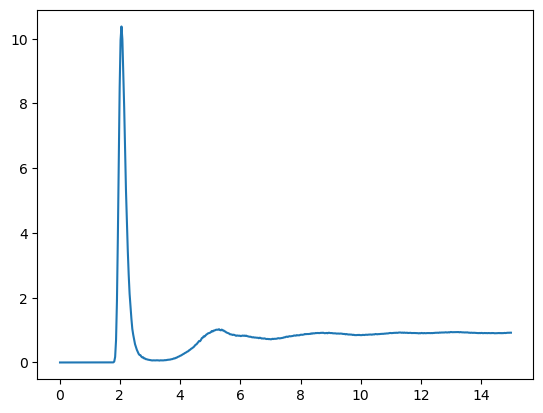

In [12]:
graph = plt.plot(rdf_solv_O.results.bins, rdf_solv_O.results.rdf)
data = graph[0].get_data()
with open('P3FO_LiFSI_solv_O_opls.csv', 'w') as myfile: 
    writer = csv.writer(myfile)
    writer.writerow(['x', 'y'])
    for i in range(len(data[0])): 
        writer.writerow([data[0][i], data[1][i]]) 

### RDF between solvent-F & Li+

In [19]:
rdf_solv_O_norm = InterRDF(li, solv_F, nbins=500, normalized=True)
rdf_solv_O_norm.run()

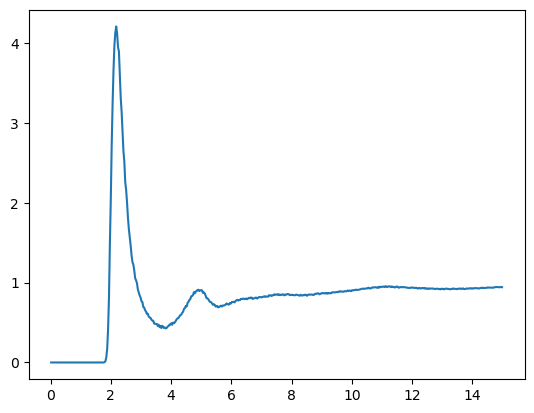

In [20]:
graph = plt.plot(rdf_solv_O_norm.results.bins, rdf_solv_O_norm.results.rdf)
data = graph[0].get_data()
with open('P3FO_LiFSI_solv_O_norm_opls.csv', 'w') as myfile: 
    writer = csv.writer(myfile)
    writer.writerow(['x', 'y'])
    for i in range(len(data[0])): 
        writer.writerow([data[0][i], data[1][i]]) 

In [21]:
rdf_solv_F = InterRDF(li, solv_F, nbins=500)
rdf_solv_F.run()

In [22]:
solv_F.atoms[3]

<Atom 20: F20 of type F of resname P3FO, resid 1 and segid SYSTEM>

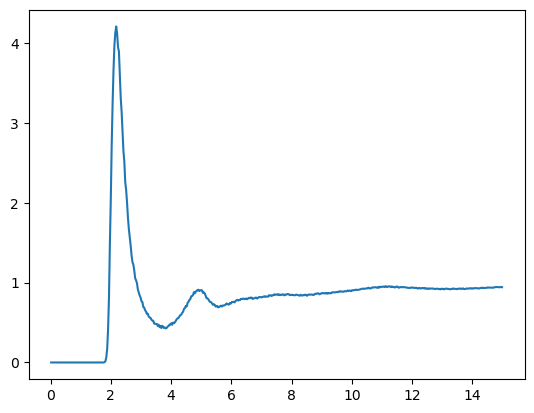

In [22]:
graph = plt.plot(rdf_solv_F.results.bins, rdf_solv_F.results.rdf)
data = graph[0].get_data()
with open('P3FO_LiFSI_solv_F_opls.csv', 'w') as myfile: 
    writer = csv.writer(myfile)
    writer.writerow(['x', 'y'])
    for i in range(len(data[0])): 
        writer.writerow([data[0][i], data[1][i]])  

In [9]:
peaks, _  = find_peaks(-rdf_solv.results.rdf, distance=5)
rdf_solv.results.bins[peaks[0]] ## cut-off for anion

3.195

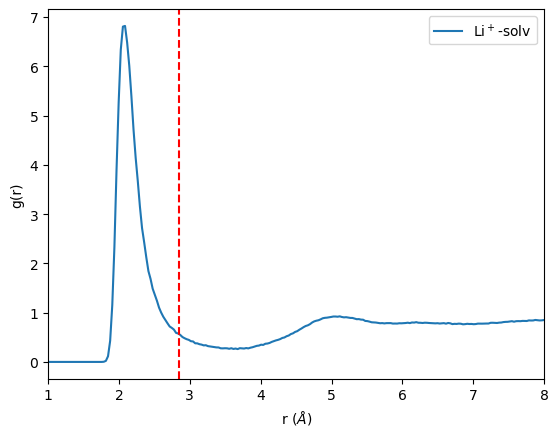

In [12]:
plt.plot(rdf_solv.results.bins, rdf_solv.results.rdf, label='Li$^+$-solv')
plt.xlim([1,8])
# plt.axvline(x=rdf_solv.results.bins[peaks[0]], color='red', linestyle='--')
plt.axvline(x=2.85, color='red', linestyle='--')
plt.xlabel('r ($\AA$)')
plt.ylabel('g(r)')
plt.legend()

In [6]:
rdf_solv = InterRDF(li, solv, nbins=500)
rdf_solv.run()

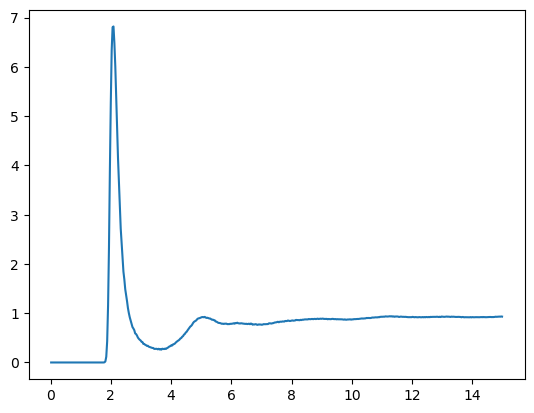

In [7]:
graph = plt.plot(rdf_solv.results.bins, rdf_solv.results.rdf)
data = graph[0].get_data()
with open('P3FO_LiFSI_solv_opls.csv', 'w') as myfile: 
    writer = csv.writer(myfile)
    writer.writerow(['x', 'y'])
    for i in range(len(data[0])): 
        writer.writerow([data[0][i], data[1][i]])

### RDF between anion & Li+/solvent

In [14]:
len(solv_F.residues.resnames)

97

In [13]:
rdf_anion = InterRDF(li, salt_, nbins=500)
rdf_anion.run()

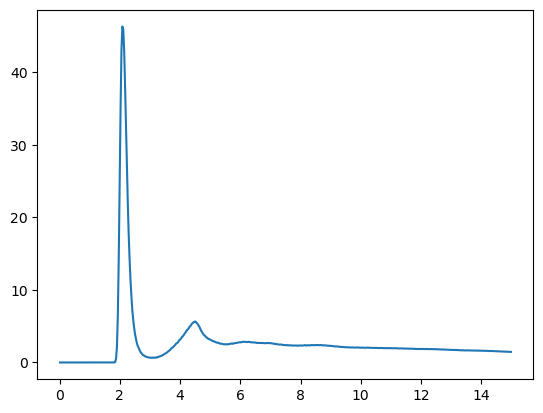

In [18]:
graph = plt.plot(rdf_anion.results.bins, rdf_anion.results.rdf)
data = graph[0].get_data()
with open('P3FO_LiFSI_anion_opls.csv', 'w') as myfile: 
    writer = csv.writer(myfile)
    writer.writerow(['x', 'y'])
    for i in range(len(data[0])): 
        writer.writerow([data[0][i], data[1][i]])  

In [27]:
rdf_solvF_anionF = InterRDF(solv_F, salt_F, nbins=500)
rdf_solvF_anionF.run()

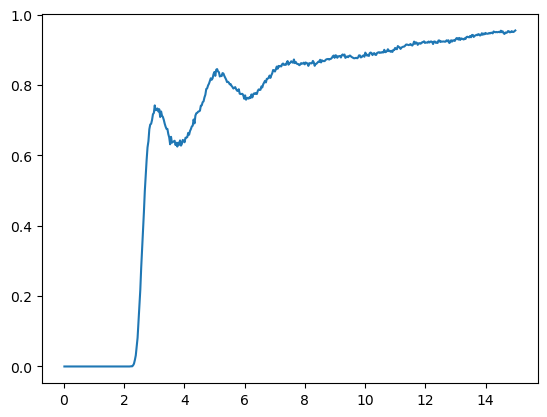

In [28]:
graph = plt.plot(rdf_solvF_anionF.results.bins, rdf_solvF_anionF.results.rdf)
data = graph[0].get_data()
with open('P3FO_LiFSI_solvF_anionF_opls.csv', 'w') as myfile: 
    writer = csv.writer(myfile)
    writer.writerow(['x', 'y'])
    for i in range(len(data[0])): 
        writer.writerow([data[0][i], data[1][i]])

In [29]:
rdf_solvF_solvF = InterRDF(solv_F, solv_F, nbins=500)
rdf_solvF_solvF.run()

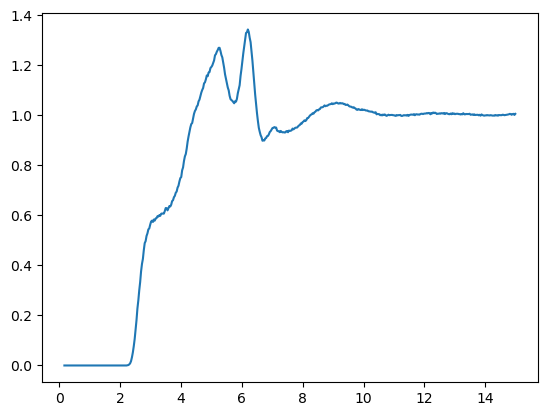

In [30]:
graph = plt.plot(rdf_solvF_solvF.results.bins[5:], rdf_solvF_solvF.results.rdf[5:])
data = graph[0].get_data()
with open('P3FO_LiFSI_solvF_solvF_opls.csv', 'w') as myfile: 
    writer = csv.writer(myfile)
    writer.writerow(['x', 'y'])
    for i in range(len(data[0])): 
        writer.writerow([data[0][i], data[1][i]])  

### RDF between anion & Li+

In [15]:
peaks, _  = find_peaks(-rdf_anion.results.rdf, distance=5)
rdf_anion.results.bins[peaks[0]] ## cut-off for anion

3.075

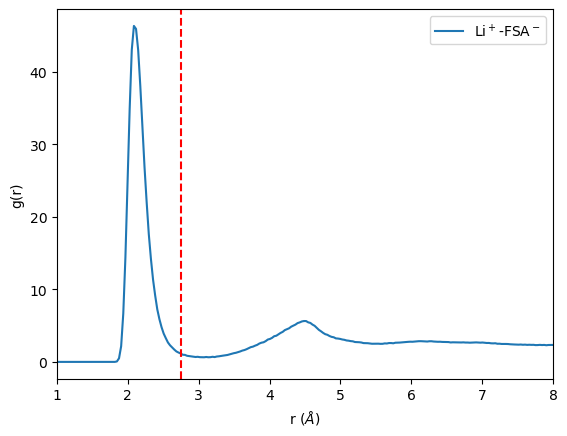

In [19]:
plt.plot(rdf_anion.results.bins, rdf_anion.results.rdf, label='Li$^+$-FSA$^-$')
plt.xlim([1,8])
# plt.axvline(x=rdf_salt.results.bins[peaks[0]], color='red', linestyle='--')
plt.axvline(x=2.75, color='red', linestyle='--')
plt.xlabel('r ($\AA$)')
plt.ylabel('g(r)')
plt.legend()

### RDF between solv-F & solv-F

In [30]:
ani_resname = 'fsa'
solv_resname = 'p3f'

sols = [ani_resname, solv_resname]
nsols = len(sols)

maxSol = 10
maxAni = 10
counts = np.zeros([maxAni,maxSol])
print(counts)

nFrame = len(u_0.trajectory)
print(nFrame)
# rcuts = 3.0*np.ones(nsols)
rcuts = [2.75, 2.85] # [anion, solvent]
print(rcuts)

dt = 1    ## in ps      
beg = 500.0      ## in ps
matRes = np.zeros((nFrame,1))
print(matRes)
end = len(u_0.trajectory)

solv_res = []
salt_res = []
solv_ctr = []
salt_ctr = []

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
2335
[2.75, 2.85]
[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]


In [ ]:
ctr = 0
for ts in u_0.trajectory[int(beg/dt):int(end/dt)]:  ## starts after the beg time defined earlier
    ctr += 1
   # print(ts)
   # print(u.trajectory.time)
   # if (u.trajectory.time > beg) and (u.trajectory.time % dta == 0):      ## somehow this condition is not working
    if  ctr % 50 == 0.0:                                                    ## divisor is the timesteps after which solvation structures are analyzed; change it accordingly
        print(u_0.trajectory.time)
        for a in li.atoms:
            print("***********************************************")
            print(a)
            agLi1=mda.core.groups.AtomGroup([a])
            # nSolRes = np.zeros((nsols,), dtype=int)
            nSolRes = [0 for i in range(nsols)]
            resIDSol = [0 for i in range(nsols)]
            solv_resid = []
            for isol in range(0,nsols):
                si=sols[isol]
                solAtms = u_0.select_atoms("resname {0:5s} and (name O* F*) and around {1:8.3f} group li1".format(si,rcuts[isol]),li1=agLi1)
                solRes = solAtms.residues
                # resIDSol = solRes.resids
                resIDSol[isol] = list(solRes.resids) ## for calculating molecule wise coordination
                # resIDSol[isol] = list(solAtms) ## for calculating atom wise coordination
                print(solAtms)
                nSolRes[isol] = len(resIDSol[isol])
                solv_resid += list(resIDSol[isol])
                print("Frame: {0:5d}, Time: {1:8.3f} ps, # solv_grp: {2:5d} ".format(ts.frame, u_0.trajectory.time, nSolRes[isol]))
#          print("-------------------------------------------------")
            counts[nSolRes[0],nSolRes[1]] += 1.0
            # if nSolRes[0] == 1 and nSolRes[1] == 3:
            #     print(solv_resid)
            #     solv_struc = u_0.atoms.select_atoms('resid {} or resid {} or resid {} or resid {}'.format(a.resid, solv_resid[0], solv_resid[1], solv_resid[2]), periodic=True)
            #     res_solv_struc = solv_struc.residues
            #     res_solv_struc.atoms.write(file_format='pdb', filename='solv-struc/dfethf_{}_{}_{}_{}.pdb'.format(a.resid,ts.frame,nSolRes[0],nSolRes[1]), frames=[ts.frame])
            #     res_solv_struc.atoms.write(file_format='xyz', filename='solv-struc/dfethf_{}_{}_{}_{}.xyz'.format(a.resid,ts.frame,nSolRes[0],nSolRes[1]), frames=[ts.frame])

In [32]:
sumCounts=np.sum(counts)
freqs=counts/sumCounts*100
# print(counts)
print(sumCounts)

conc_salt = 1 ## change it accordingly
file_name = 'solv_dist_' + solv_resname + '_' + ani_resname + '_' + str(conc_salt) + '0.08.csv'
fo=open(file_name,"w")
fo.write("anion_number,solvent_number,distribution_percentage\n")

for i1 in range(maxAni):
    for i2 in range(maxSol):
        if freqs[i1,i2]>0.0:
            print("{:5d} {:5d} {:8.3f}".format(i1,i2,freqs[i1,i2]) )
            fo.write("{:5d},{:5d},{:.3f}\n".format(i1,i2,freqs[i1,i2]))
fo.close()

2808.0
    0     2    2.066
    0     3    3.312
    0     4    1.068
    1     1    3.348
    1     2   14.209
    1     3    2.244
    1     4    0.071
    2     1   18.162
    2     2   10.613
    2     3    0.463
    3     0    0.748
    3     1   15.848
    3     2    4.274
    4     0    7.870
    4     1    6.410
    4     2    0.107
    5     0    7.158
    5     1    0.570
    6     0    1.460


In [ ]:
# print(solAtms.atoms)
# nSolRes[2]
# tt = solAtms.atoms[0]
# tt.element
# solAtms.atoms.elements
solv_resid[2].

242

### Save correct solvation structures

In [ ]:
ctr = 0
for ts in u_0.trajectory[int(beg/dt):int(end/dt)]:  ## starts after the beg time defined earlier
    ctr += 1
   # print(ts)
   # print(u.trajectory.time)
   # if (u.trajectory.time > beg) and (u.trajectory.time % dta == 0):      ## somehow this condition is not working
    if  ctr % 200 == 0.0:                                                    ## divisor is the timesteps after which solvation structures are analyzed; change it accordingly
        print(u_0.trajectory.time)
        for a in li.atoms:
            print("***********************************************")
            print(a)
            agLi1=mda.core.groups.AtomGroup([a])
            # nSolRes = np.zeros((nsols,), dtype=int)
            nSolRes = [0 for i in range(nsols)]
            resIDSol = [0 for i in range(nsols)]
            solv_resid = []
            for isol in range(0,nsols):
                si=sols[isol]
                solAtms = u_0.select_atoms("resname {0:5s} and (name O* F*) and around {1:8.3f} group li1".format(si,rcuts[isol]),li1=agLi1)
                solRes = solAtms.residues
                # resIDSol = solRes.resids
                resIDSol[isol] = list(solRes.resids) ## for calculating molecule wise coordination
                # resIDSol[isol] = list(solAtms) ## for calculating atom wise coordination
                print(solAtms)
                nSolRes[isol] = len(resIDSol[isol])
                solv_resid += list(resIDSol[isol])
                print("Frame: {0:5d}, Time: {1:8.3f} ps, # solv_grp: {2:5d} ".format(ts.frame, u_0.trajectory.time, nSolRes[isol]))
                # print("-------------------------------------------------")
            counts[nSolRes[0],nSolRes[1]] += 1.0
            if nSolRes[0] == 2 and nSolRes[1] == 1:
                print(solv_resid)
                solv_struc = u_0.atoms.select_atoms('resid {} or resid {} or resid {} or resid {}'.format(a.resid, solv_resid[0], solv_resid[1], solv_resid[2]), periodic=True)
                # Apply minimum image convention
                box = u_0.dimensions[:3]
                li_pos = a.position
                
                for atom in solv_struc.atoms:
                    if atom.resid != a.resid:
                        delta = atom.position - li_pos
                        # Apply minimum image convention
                        delta = delta - box * np.round(delta / box)
                        atom.position = li_pos + delta
                
                solv_struc.write('solv-struc/p3fo-fsi_{}_{}_{}_{}_{}.pdb'.format(
                    a.resid, ts.frame, nSolRes[0], nSolRes[1], ''.join(solAtms.atoms.elements)
                ))

### Residence times & coordination numbers

In [11]:
solvents = {"P3FO": solvent,
            "FSI": anion}

solute = Solute.from_atoms(li, solvents, solute_name="Li")
solute.run(step=1) # Run through the trajectory

In [12]:
# 4. Calculate Residence Times
res = Residence.from_solute(solute)

# Access the 'fit' residence time (tau)
# This uses the Autocorrelation Function (ACF) which is more physically 
# accurate than a simple frame-by-frame count.
print(f"Li-P3FO Residence Time: {res.residence_times_fit['P3FO']:.2f} ps")
print(f"Li-FSI Residence Time: {res.residence_times_fit['FSI']:.2f} ps")

Li-P3FO Residence Time: 6981.37 ps
Li-FSI Residence Time: 3117.37 ps


In [17]:
cn = solute.coordination.coordination_numbers
cn

{'FSI': 2.4918464832811726, 'P3FO': 1.2541700982814472}

In [18]:
D = res.residence_times_fit['P3FO'] * cn['P3FO'] + res.residence_times_fit['FSI'] * cn['FSI']
print(f"Effective Residence Time (D): {D:.2f} ps")

Effective Residence Time (D): 16523.83 ps
